# GANs and Autoencoders / VAEs

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build a simple **autoencoder** (encoder → latent → decoder) and reconstruct images (e.g. MNIST)
- Understand the idea of **GAN** (generator vs discriminator) and **VAE** (probabilistic latent)
- See why we use a GAN (instead of a single generator) and why we use autoencoders for compression/denoising

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 5, lesson 04 "Simple GAN Experiment: Learning to Generate Real 911-Call Locations" — you watched a generator and a discriminator compete there; here the autoencoder half of the family joins them.

**Used later in:** Course 10 (AIAT 124) — Unit 1, lesson 05 "Building and Training a Simple GAN".

---

## 🌍 Real life

**📌 Real case — the deep autoencoder that restarted deep learning.** Hinton and Salakhutdinov (*Science* 313, 2006, [doi:10.1126/science.1127647](https://doi.org/10.1126/science.1127647)) trained a deep autoencoder — a multilayer network with a small central layer, reconstructing its own high-dimensional input — and reported codes "that work much better than principal components analysis as a tool to reduce the dimensionality of data". That paper is one of the results that made deep networks credible again, and the shape you build below is the same shape, one layer deep instead of four: they used **784-1000-500-250-30** on MNIST, we use **784-128-32**; both encode to a narrow bottleneck, decode back, and measure reconstruction error. On the generative side, Goodfellow et al. (2014) added the adversary; by CVPR 2019 Karras, Laine and Aila's **StyleGAN** came with a new face dataset of its own — **FFHQ, 70,000 images at 1024×1024** — which the paper introduces as offering "much higher quality and covers considerably wider variation than existing high-resolution datasets".

**⚡ Why this matters — what goes wrong without it.** An autoencoder trained on reconstruction error alone learns to *copy*. Nothing in MSE tells it what a **plausible** digit looks like — only what the average pixel should be, which is exactly why autoencoder outputs are soft and blurry. Our reconstruction loss reached **0.0233** after 12 epochs — flat enough that the blur is not undertraining — and the images below are recognisable and smudged. The discriminator supplies the missing signal: a second network whose only job is to say "a real digit does not look like that". That is why GANs produce sharp images and plain autoencoders do not, and it is the single idea worth taking from this notebook.

**Where is this used?** Autoencoders are used for **denoising**, **compression**, and **anomaly detection**. GANs are used for **image generation**, **style transfer**, and **data augmentation**. VAEs are used for **generative models** and **latent representation**.

**In this notebook we use** an **autoencoder** to **reconstruct** MNIST digits (encoder compresses, decoder reconstructs). We use an **autoencoder** (instead of a plain NN) **because** it learns a **latent representation**; we use **GANs** (generator + discriminator) **instead of** a single generator **because** the discriminator gives a **training signal** (real vs fake) so the generator improves.

**📌 Covers slide(s):** **04** (AutoEncoders), **09** (GANs). *Do this notebook after those slides.*

---

**Before starting:** Run the imports cell below.


⏱ **Runtime:** about **1 minute on CPU** — the autoencoder trains in a couple of seconds, the GAN's 10 epochs over MNIST take most of the rest.

## Theory (short)

- **Autoencoder:** Encoder maps input → **latent** (smaller); decoder maps latent → **reconstruction**. Loss = reconstruction error (e.g. MSE). Used for compression, denoising, anomaly detection.
- **GAN:** **Generator** produces fake samples; **Discriminator** tries to tell real vs fake. They train against each other. We use GAN (instead of only a generator) because the discriminator provides a learning signal for "what looks real."
- **VAE:** Variational autoencoder; latent is **probabilistic** (mean + variance); we sample from the latent and decode. Balances reconstruction and regularized latent.
- **We use autoencoder here** for a quick reconstruction demo; GAN/VAE would be separate notebooks for generation.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, Matplotlib. MNIST (small subset). We build a simple autoencoder.

**Dataset:** Real — MNIST (small subset).

**Outputs:** Model summary, training loss (reconstruction), and one figure: **original vs reconstructed** images (with axis labels).

## Step 1: Imports and load MNIST

In [1]:
# Step 1: Imports and load MNIST subset for autoencoder
# WHY: an autoencoder learns to reproduce its input, so the images serve as both X and target.
import numpy as np
import matplotlib.pyplot as plt

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    # Scale pixels to 0-1, flatten to 784-long vectors, and keep small subsets for a fast run.
    (x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    x_train = x_train.reshape(-1, 784)
    x_test = x_test.reshape(-1, 784)
    x_train, x_test = x_train[:5000], x_test[:1000]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (5000, 784) Test: (1000, 784)


## Step 2: Build autoencoder (we use encoder + decoder instead of a single layer to learn a compressed latent)

In [2]:
# WHAT: build a plain autoencoder - 784 -> 32 -> 784 - trained to reproduce its own input.
# WHY: forcing data through a 32-number bottleneck makes the network learn a compressed representation.
if HAS_TF:
    # Fix every random seed so the loss numbers quoted in this lesson match your run.
    keras.utils.set_random_seed(42)
    latent_dim = 32
    # Encoder: compress the 784 pixels down to 32 latent numbers.
    encoder = keras.Sequential([
        keras.layers.Dense(128, activation="relu", input_shape=(784,)),
        keras.layers.Dense(latent_dim, activation="relu"),
    ])
    # Decoder: rebuild the 784 pixels from those 32 numbers; sigmoid keeps outputs in 0-1.
    decoder = keras.Sequential([
        keras.layers.Dense(128, activation="relu", input_shape=(latent_dim,)),
        keras.layers.Dense(784, activation="sigmoid"),
    ])
    # Chain encoder and decoder, then train with MSE so output matches input.
    inp = keras.Input(shape=(784,))
    latent = encoder(inp)
    out = decoder(latent)
    autoencoder = keras.Model(inp, out)
    autoencoder.compile(optimizer="adam", loss="mse")
    autoencoder.summary()

/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32)             │       104,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 784)            │       105,360 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train (12 epochs, ~2 s on CPU) and plot original vs reconstructed vs the error between them

epoch | validation reconstruction loss (MSE)
    1 | 0.0680
    2 | 0.0551
    4 | 0.0407
    8 | 0.0291
   12 | 0.0233


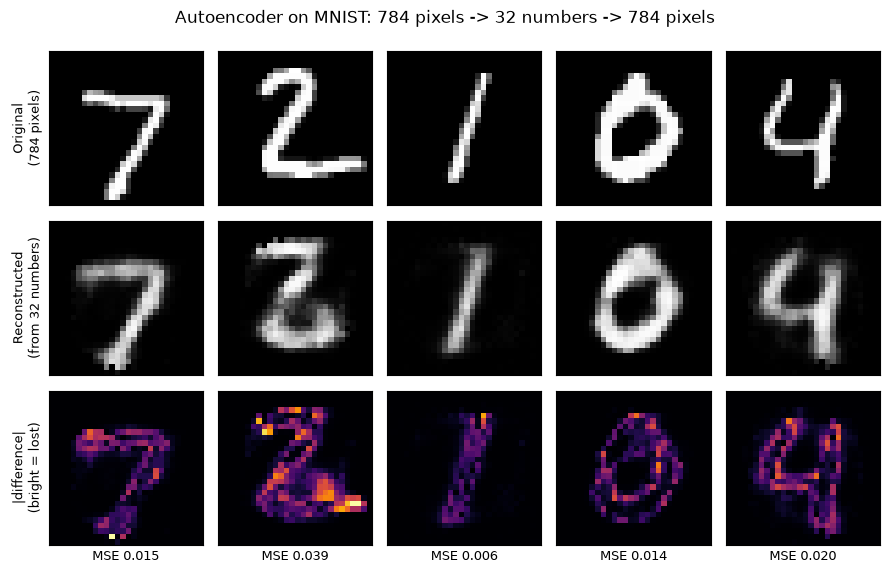

Reconstruction loss (last): 0.0233


In [3]:
# WHAT: train the autoencoder, then show input, reconstruction, and the error between them.
# WHY: the error map says exactly WHICH detail a 32-number bottleneck throws away.
if HAS_TF:
    # Note the targets are x_train itself: the autoencoder learns input -> input.
    history = autoencoder.fit(x_train, x_train, validation_data=(x_test, x_test),
                              epochs=12, batch_size=128, verbose=0)

    # Loss at a few epochs: it has flattened, so any blur below is NOT undertraining.
    print("epoch | validation reconstruction loss (MSE)")
    for e in (1, 2, 4, 8, 12):
        print(f"{e:5d} | {history.history['val_loss'][e - 1]:.4f}")

    recons = autoencoder.predict(x_test[:5], verbose=0)
    per_img_mse = ((recons - x_test[:5]) ** 2).mean(axis=1)
    diffs = np.abs(recons[:5] - x_test[:5]).reshape(5, 28, 28)
    dmax = float(diffs.max())  # one shared scale so the five error maps are comparable

    # Row 1 = what went in, row 2 = what came back out of 32 numbers, row 3 = where they differ.
    fig, axs = plt.subplots(3, 5, figsize=(9.0, 5.8))
    row_labels = ["Original\n(784 pixels)", "Reconstructed\n(from 32 numbers)",
                  "|difference|\n(bright = lost)"]
    for i in range(5):
        axs[0, i].imshow(x_test[i].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        axs[1, i].imshow(recons[i].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        axs[2, i].imshow(diffs[i], cmap="inferno", vmin=0, vmax=dmax)
        axs[2, i].set_xlabel(f"MSE {per_img_mse[i]:.3f}", fontsize=9)
        for r in range(3):
            axs[r, i].set_xticks([])
            axs[r, i].set_yticks([])
    for r in range(3):
        axs[r, 0].set_ylabel(row_labels[r], fontsize=9)
    fig.suptitle("Autoencoder on MNIST: 784 pixels -> 32 numbers -> 784 pixels", fontsize=12)
    fig.tight_layout()
    plt.show()
    print("Reconstruction loss (last): %.4f" % history.history["val_loss"][-1])


**Read the figure.** Top row: five test digits the network never trained on. Middle row: the same
digits after being squeezed through a **32-number** code and rebuilt — still readable as 7, 2, 1, 0, 4,
and every one visibly *softer* than the original. Bottom row: the absolute difference on one shared
brightness scale, so the five maps are comparable; the bright pixels trace the **outline of each
stroke** — the sharp edges are exactly the detail mean-squared error is content to average away. The
per-image MSE under each column agrees with your eye: the 2, the messiest reconstruction, carries the
largest error (0.039); the thin 1, the easiest shape, the smallest (0.006).

The validation loss printed above falls from 0.0680 to 0.0233 and is flattening by epoch 12, so the
softness is **not undertraining** — it is what minimising MSE looks like. That missing sharpness is the
gap the GAN's discriminator exists to fill, and it is the argument for the next cell.

## 🌍 Real-World Worked Example — GAN Generating Handwritten Digits

**Industry context:**
- **Face synthesis:** StyleGAN (Karras, Laine & Aila, CVPR 2019) came with a dataset of its own — FFHQ, 70,000 images at 1024×1024 — introduced in the paper as offering "much higher quality and covers considerably wider variation than existing high-resolution datasets".
- **The mechanism every item on this list inherits:** Goodfellow et al. (2014) introduced the generator/discriminator pair you are about to build.
- **How to read any GAN claim you meet:** ask which dataset and which metric. "The samples look good" is not a measurement, and this is the one area of deep learning where that sentence still gets published.

We train a **GAN** (fully-connected generator and discriminator) to generate handwritten digit images from pure noise. *(A DCGAN — Radford et al. 2015 — uses convolutional layers instead of `Linear` ones; the adversarial training loop is identical.)*

Epoch 1/10 — D loss: 0.678  G loss: 1.527


Epoch 2/10 — D loss: 0.724  G loss: 1.704


Epoch 3/10 — D loss: 0.560  G loss: 3.035


Epoch 4/10 — D loss: 0.471  G loss: 2.929


Epoch 5/10 — D loss: 0.280  G loss: 3.017


Epoch 6/10 — D loss: 0.359  G loss: 2.719


Epoch 7/10 — D loss: 0.996  G loss: 5.652


Epoch 8/10 — D loss: 0.664  G loss: 2.155


Epoch 9/10 — D loss: 0.669  G loss: 2.707


Epoch 10/10 — D loss: 0.756  G loss: 1.615


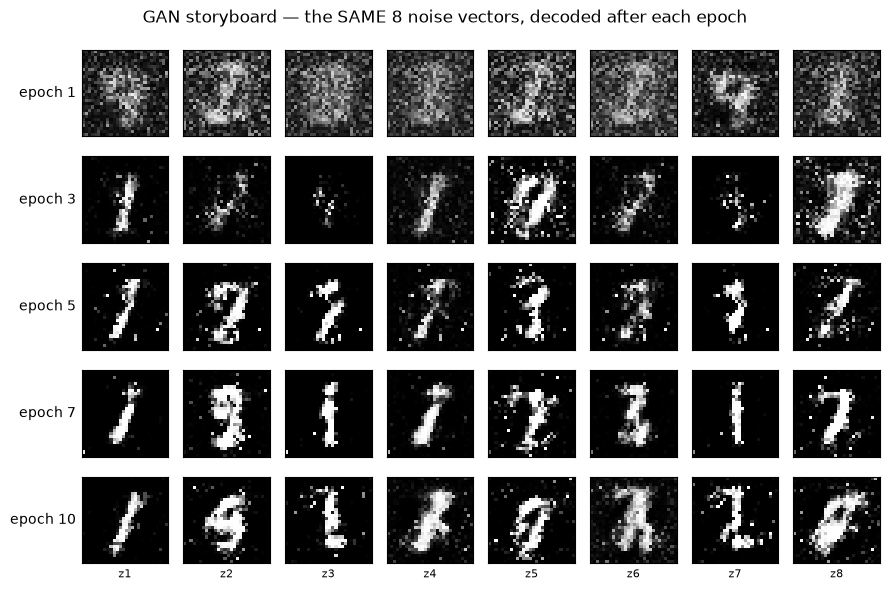

epoch   D loss   G loss   row in figure above
    1    0.678    1.527   <-- shown
    2    0.724    1.704   
    3    0.560    3.035   <-- shown
    4    0.471    2.929   
    5    0.280    3.017   <-- shown
    6    0.359    2.719   
    7    0.996    5.652   <-- shown
    8    0.664    2.155   
    9    0.669    2.707   
   10    0.756    1.615   <-- shown


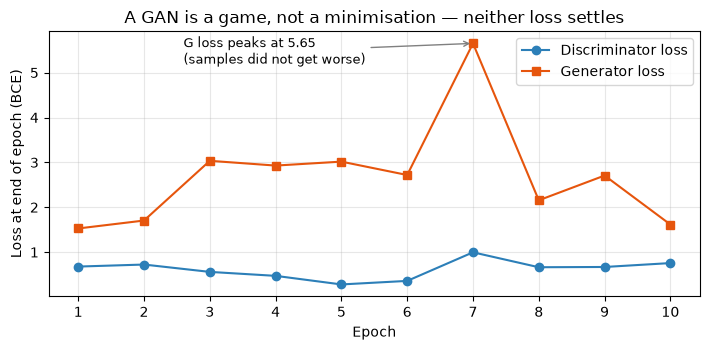

In [4]:
# WHAT: train a GAN on MNIST, photographing the SAME noise vectors after several epochs.
# WHY: a GAN's loss cannot tell you whether it is working - only a picture of its samples can.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

transform = T.Compose([T.ToTensor(), T.Normalize([0.5],[0.5])])
dataset   = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=transform)
loader    = torch.utils.data.DataLoader(dataset, batch_size=BATCH, shuffle=True)

# ── Generator: noise → image ───────────────────────────────────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
# ── Discriminator: image → real/fake ─────────────────────────────────────
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))
bce   = nn.BCELoss()

# Eight FIXED noise vectors, drawn from their own generator so the training run below is
# bit-for-bit what it was before this snapshot code existed. Decoding the same eight points
# after every epoch is what turns a pile of samples into a storyboard.
fixed_z = torch.randn(8, LATENT_DIM, generator=torch.Generator().manual_seed(7))
SNAP_EPOCHS = [1, 3, 5, 7, 10]
snapshots = {}

d_losses, g_losses = [], []
for epoch in range(10):
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        # ── Train Discriminator ─────────────────────────────────────────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()
        loss_D = bce(D(real_flat), torch.ones(bs,1)) + bce(D(fake), torch.zeros(bs,1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # ── Train Generator ─────────────────────────────────────────────
        z      = torch.randn(bs, LATENT_DIM)
        fake   = G(z)
        loss_G = bce(D(fake), torch.ones(bs,1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    d_losses.append(loss_D.item()); g_losses.append(loss_G.item())
    # Photograph the generator at this epoch (costs one forward pass on 8 vectors).
    if (epoch + 1) in SNAP_EPOCHS:
        with torch.no_grad():
            snapshots[epoch + 1] = G(fixed_z).view(8, 28, 28).numpy()
    print(f"Epoch {epoch+1}/10 — D loss: {d_losses[-1]:.3f}  G loss: {g_losses[-1]:.3f}")

# ── Storyboard: one row per snapshot epoch, one column per fixed noise vector ──
fig, axes = plt.subplots(len(SNAP_EPOCHS), 8, figsize=(9.0, 6.0))
for r, ep in enumerate(SNAP_EPOCHS):
    for c in range(8):
        axes[r, c].imshow(snapshots[ep][c], cmap='gray', vmin=-1, vmax=1)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[r, 0].set_ylabel(f"epoch {ep}", fontsize=10, rotation=0, ha='right', va='center')
for c in range(8):
    axes[-1, c].set_xlabel(f"z{c+1}", fontsize=8)
fig.suptitle("GAN storyboard — the SAME 8 noise vectors, decoded after each epoch", fontsize=12)
fig.tight_layout()
plt.show()

# The step table behind the storyboard: which row of the picture each epoch produced.
print(f"{'epoch':>5} {'D loss':>8} {'G loss':>8}   row in figure above")
for i, (dl, gl) in enumerate(zip(d_losses, g_losses), start=1):
    print(f"{i:5d} {dl:8.3f} {gl:8.3f}   {'<-- shown' if i in SNAP_EPOCHS else ''}")

# ── The losses that refuse to converge, over the same ten epochs ──
fig, ax = plt.subplots(figsize=(7.2, 3.6))
epochs = np.arange(1, 11)
ax.plot(epochs, d_losses, 'o-', color='#2c7fb8', label='Discriminator loss')
ax.plot(epochs, g_losses, 's-', color='#e6550d', label='Generator loss')
peak = int(np.argmax(g_losses))
ax.annotate(f"G loss peaks at {g_losses[peak]:.2f}\n(samples did not get worse)",
            xy=(peak + 1, g_losses[peak]), xytext=(peak - 3.4, g_losses[peak] * 0.92),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='grey'))
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss at end of epoch (BCE)")
ax.set_xticks(epochs)
ax.set_title("A GAN is a game, not a minimisation — neither loss settles")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


**Read the two figures together — this pair is the point of the lesson.**

*Storyboard (first figure).* Every column is one fixed noise vector, so a column is the **same point in
latent space** decoded five times during training. Read **down a column**: at epoch 1 all eight are
cloudy grey texture, by epoch 5 a bright stroke has separated from the background, and by epoch 10 the
same point has become a digit-like shape on a black field. Read the **bottom row across**: eight
different noise vectors give visibly different shapes — loops under z2, z6 and z8, thin strokes under
z1, z3 and z7. They are not all convincing digits, but they are not the *same* image either, and that
is the check for **mode collapse**, which would show as one shape repeated eight times.

*Loss curves (second figure).* Over exactly those ten epochs neither loss walks downhill: the
discriminator loss wanders between 0.28 and 1.00 and ends higher than it started, and the generator
loss spikes to 5.65 at epoch 7 — yet the epoch-7 row of the storyboard is not worse than epoch 5. The
samples improved while the losses did not, so **the loss curve cannot tell you when to stop, and cannot
rank two GANs.** Everywhere else in this course a falling loss meant progress; here it only means one
player is temporarily winning. The picture is the measurement.

## 💬 Discuss

1. In every other notebook in this course, a falling loss meant progress. Our D and G losses oscillate and never settle — yet the samples improve. So what do you actually *look at* to decide this GAN is working, and how would you write that criterion into a training script that runs unattended overnight?
2. The autoencoder squeezed 784 numbers into 32 and reconstructed recognisable digits. Is that compression, or has it memorised roughly ten average shapes? Design a test that tells the two apart — you may only use the model and MNIST.
3. A colleague proposes generating synthetic patient records with a GAN so that the real ones never leave the hospital. Name two things that could go wrong which the loss curve would not reveal, and say who in the hospital should be in the room for that decision.


## ⚠️ Where this breaks

**Read our own GAN loss numbers before you trust any GAN loss number.**

- D loss ran **0.678 → 0.724 → 0.560 → 0.471 → 0.280 → 0.359 → 0.996 → 0.664 → 0.669 → 0.756**, and G loss swung from **1.527 up to 5.652** and back to **1.615**. These do not converge, and they are not supposed to: a GAN is a two-player game, not a minimisation. **You cannot use the loss to decide when to stop training, or to decide which of two GANs is better.** Everywhere else in this course, falling loss meant progress. Here it means one player is winning.
- **Mode collapse.** The generator can discover a single digit that reliably fools the discriminator and produce only that, forever. The losses will look unremarkable while it happens. The only reliable detection is to look at a grid of samples — which is why every GAN notebook ends with a picture.
- **The autoencoder's compression is domain-locked.** A 32-number bottleneck trained on MNIST will "compress" a photograph of a car into nonsense, confidently and without error. Reconstruction quality is only meaningful inside the training distribution.
- **The assumption that must hold for the autoencoder:** your test data comes from the same distribution as your training data. That is exactly the assumption `02` deliberately breaks in order to build an anomaly detector out of it.
- **Cheaper alternatives:** for image compression, JPEG. For dimensionality reduction on tabular data, PCA — closed-form, no training loop, and for a linear autoencoder with MSE it spans the same subspace anyway. Reach for an autoencoder when the structure is genuinely non-linear.
- **What largely replaced GANs for generation:** diffusion models (Ho, Jain & Abbeel 2020 — reference 3 below) optimise a stable, well-defined objective and simply do not have the convergence problem you can see in our loss table. Learn GANs for the adversarial idea; expect to deploy diffusion.


## 🧩 Mini-exercise

**Try it (choose one):** Reduce the autoencoder's latent dimension (e.g. 32 → 8) and retrain. How does reconstruction quality change? Or add one more Dense layer in the encoder and decoder and compare.

---

## ✅ Summary

**What you did:** Built an autoencoder (encoder → latent → decoder), trained it to reconstruct MNIST, and plotted original vs reconstructed.

**In real life you'd also:** Use convolutional autoencoders, VAEs (with KL loss), or GANs (generator + discriminator) for generation.

**The main idea:** Autoencoders learn a compressed representation (latent); GANs use a discriminator to train a generator; VAEs add a probabilistic latent.

**Next:** `02_implementing_a_vae_variational_autoencoder_for_anomaly_detection` covers VAE; `03_reinforcement_learning_fundamentals_deep_q_networks_policy_gradients` covers RL.

## 🔭 State of the field (2026)

For image generation, the live lineage in 2026 does not run through GANs. It runs latent diffusion (arXiv 2112.10752) → transformer diffusion backbones (DiT, arXiv 2212.09748) → flow matching (arXiv 2210.02747), and from there into models that understand *and* generate in one network (survey: arXiv 2505.02567; a 2026 example: arXiv 2603.06577). A curriculum that teaches image generation only through GANs is teaching the archaeology.

**The autoencoder you built is not archaeology — it is a live component.** Latent diffusion is called latent because it diffuses inside an autoencoder's compressed space rather than in pixels; the encoder/decoder pair on this page is literally the part that makes modern image generation affordable. The VAE's probabilistic latent is also the direct ancestor of the noise-to-data mapping every diffusion and flow model learns.

**And the GAN half earns its place for a reason few other lessons can offer.** It is the clearest example in the whole course of a training run where the loss curve tells you nothing — a two-player game, not a minimisation. The oscillating losses recorded in *Where this breaks* are a permanent lesson about trusting a metric, whatever architecture you end up using.


## 📚 References

1. Goodfellow, I. et al. (2014). *Generative Adversarial Networks*. NeurIPS. https://arxiv.org/abs/1406.2661
2. Kingma, D. P. & Welling, M. (2014). *Auto-Encoding Variational Bayes* (VAE). ICLR. https://arxiv.org/abs/1312.6114
3. Ho, J., Jain, A. & Abbeel, P. (2020). *Denoising Diffusion Probabilistic Models*. NeurIPS. https://arxiv.org/abs/2006.11239
4. Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning* (ch. 14, Autoencoders). MIT Press. https://www.deeplearningbook.org/
5. Hinton, G. E. & Salakhutdinov, R. R. (2006). *Reducing the Dimensionality of Data with Neural Networks*. Science 313(5786), 504-507. https://doi.org/10.1126/science.1127647
6. Karras, T., Laine, S. & Aila, T. (2019). *A Style-Based Generator Architecture for Generative Adversarial Networks* (StyleGAN, FFHQ dataset). CVPR. https://arxiv.org/abs/1812.04948

**Where generative modelling actually went (2021–2026)**

7. Rombach et al. (2021). *High-Resolution Image Synthesis with Latent Diffusion Models*. arXiv. https://arxiv.org/abs/2112.10752 — the architecture behind the open image-generation ecosystem — and the direct descendant of the autoencoder you built here: it diffuses inside a learned latent space rather than in pixels.
8. Peebles & Xie (2022). *Scalable Diffusion Models with Transformers* (DiT). arXiv. https://arxiv.org/abs/2212.09748 — replaced the U-Net backbone with a transformer and gave diffusion a scaling law.
9. Lipman et al. (2022). *Flow Matching for Generative Modeling*. arXiv. https://arxiv.org/abs/2210.02747 — simulation-free continuous flows — the formulation behind current few-step generators.
10. Zhang et al. (2025). *Unified Multimodal Understanding and Generation Models: Advances, Challenges, and Opportunities*. arXiv. https://arxiv.org/abs/2505.02567 — the 2025 orientation survey for models that both understand and generate images in one network.
11. Li et al. (2026). *Omni-Diffusion: Unified Multimodal Understanding and Generation with Masked Discrete Diffusion*. arXiv. https://arxiv.org/abs/2603.06577 — a 2026 example of that convergence: discrete diffusion used as a single mechanism for understanding *and* generation.
